# Multilingual Health Question Answering in Low-Resource African Languages
## ALU — ML Techniques I | Zindi Competition | Edwin Bayingana

This notebook documents ten retrieval and generation experiments on the Zindi
Multilingual Health QA challenge. The task is to answer health questions across
eight language subsets covering English, Akan, Amharic, Luganda, and Swahili.

| Experiment | Model / Method | Category |
|------------|---------------|----------|
| 1 | TF-IDF per-subset retrieval | Sparse retrieval baseline |
| 2 | mT5-base zero-shot generation | Generative baseline |
| 3 | MPNet multilingual semantic retrieval | Dense retrieval |
| 4 | MPNet hybrid TF-IDF + semantic | Dense + sparse |
| 5 | LaBSE semantic retrieval | Dense retrieval |
| 6 | LaBSE hybrid tuned per language | Dense + sparse (tuned) |
| 7 | E5-Large semantic retrieval | Dense retrieval |
| 8 | E5-Large hybrid tuned per language | Dense + sparse (tuned) |
| 9 | LaBSE two-stage reranking | Retrieve + rerank |
| 10 | LaBSE + E5 MBR ensemble | Multi-model ensemble |

> **Runtime note**: Embeddings are cached to `/kaggle/working/` after first encoding.
> Subsequent runs load from disk and complete in under 10 minutes per experiment.


## 1 — Environment Setup

In [1]:
import os, subprocess, sys

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_VISIBLE_DEVICES"]    = "0"
os.environ["TOKENIZERS_PARALLELISM"]  = "false"
os.environ["HF_HUB_VERBOSITY"]        = "error"

# Install packages and suppress dependency conflict noise
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "sentence-transformers", "transformers", "datasets",
     "rouge-score", "sentencepiece", "protobuf"],
    capture_output=True, text=True
)
errors = [l for l in result.stderr.splitlines() if l.startswith("ERROR")]
if errors:
    print("\n".join(errors))
else:
    print("Packages installed successfully.")


Packages installed successfully.


### Library Setup and Environment Configuration

The logging level for `transformers`, `sentence_transformers`, and `huggingface_hub` 
is set to ERROR before any model is loaded. This suppresses three categories of 
verbose output that appear in Kaggle sessions: HuggingFace Hub authentication notices, 
model weight loading reports (`embeddings.position_ids UNEXPECTED`), and progress bars 
from model downloads. The random seed (42) is fixed across NumPy and PyTorch to ensure 
reproducible embedding outputs.

In [2]:
import re, gc, time, unicodedata, warnings, logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

warnings.filterwarnings("ignore")

# Suppress verbose model load reports and hub authentication notices
for logger_name in [
    "transformers", "sentence_transformers",
    "huggingface_hub", "sentence_transformers.SentenceTransformer",
]:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_GPUS = torch.cuda.device_count()
OUT    = Path("/kaggle/working")

print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    for i in range(N_GPUS):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {props.name}  {props.total_memory / 1e9:.1f} GB")


Device : cuda
  GPU 0: Tesla T4  15.6 GB


In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_NAME = "health-qa-african"         
DATA_DIR     = Path(f"/kaggle/input/datasets/edwinbayingana/{DATASET_NAME}")

# ── Column names ───────────────────────────────────────────────────────────────
Q_COL    = "input"
A_COL    = "output"
LANG_COL = "subset"
ID_COL   = "ID"

DEFAULT_ANSWER = (
    "Good health requires balanced nutrition, regular physical activity, "
    "adequate sleep, and access to preventive healthcare services."
)

# ── Model identifiers ──────────────────────────────────────────────────────────
MPNET = "paraphrase-multilingual-mpnet-base-v2"
LABSE = "sentence-transformers/LaBSE"
E5    = "intfloat/multilingual-e5-large"
MT5   = "google/mt5-base"

# ── Default retrieval strategy per language subset ─────────────────────────────
# Each entry: (method, tfidf_weight, semantic_weight)
LANGUAGE_STRATEGY = {
    "Amh_Eth": ("semantic", 0.00, 1.00),
    "Aka_Gha": ("hybrid",   0.20, 0.80),
    "Eng_Eth": ("hybrid",   0.40, 0.60),
    "Eng_Gha": ("hybrid",   0.40, 0.60),
    "Eng_Ken": ("hybrid",   0.40, 0.60),
    "Eng_Uga": ("hybrid",   0.40, 0.60),
    "Lug_Uga": ("hybrid",   0.25, 0.75),
    "Swa_Ken": ("hybrid",   0.25, 0.75),
}

# ── Language display names for prompt construction (Exp 2) ────────────────────
LANG_NAMES = {
    "Eng": "English", "Aka": "Akan", "Amh": "Amharic",
    "Lug": "Luganda", "Swa": "Swahili",
}

print("Configuration loaded.")
for f in ["Train.csv", "Val.csv", "Test.csv", "SampleSubmission.csv"]:
    status = "found" if (DATA_DIR / f).exists() else "NOT FOUND"
    print(f"  {f}: {status}")


Configuration loaded.
  Train.csv: found
  Val.csv: found
  Test.csv: found
  SampleSubmission.csv: found


### Dataset Overview

The dataset contains 29,814 training examples, 6,686 validation examples, and 2,618 
test questions distributed across 8 language subsets. `Eng_Uga` (7,623 samples) 
dominates while `Amh_Eth` (1,845) is the most data-scarce subset. The evaluation 
protocol fits all retrieval models on training data only, then evaluates on the full 
validation set. For test submissions, the corpus is expanded to include validation 
data (36,500 total documents), giving the retrieval index more candidates to draw from.

In [4]:
train  = pd.read_csv(DATA_DIR / "Train.csv")
val    = pd.read_csv(DATA_DIR / "Val.csv")
test   = pd.read_csv(DATA_DIR / "Test.csv")
sample = pd.read_csv(DATA_DIR / "SampleSubmission.csv")

# Clean train and val — remove rows with missing question or answer
for df in [train, val]:
    df[Q_COL] = df[Q_COL].fillna("").astype(str).str.strip()
    df[A_COL] = df[A_COL].fillna("").astype(str).str.strip()
train = train[(train[Q_COL] != "") & (train[A_COL] != "")].reset_index(drop=True)
val   = val[(val[Q_COL]   != "") & (val[A_COL]   != "")].reset_index(drop=True)

# Test — keep all rows; replace blank questions with the default
test[Q_COL]    = test[Q_COL].fillna("").astype(str).str.strip()
test[Q_COL]    = test[Q_COL].replace("", DEFAULT_ANSWER)
test[LANG_COL] = test[LANG_COL].fillna("Eng_Uga").astype(str).str.strip()
test[ID_COL]   = test[ID_COL].astype(str).str.strip()
sample[ID_COL] = sample[ID_COL].astype(str).str.strip()

assert len(test) == len(sample), (
    f"Test rows ({len(test)}) do not match sample submission ({len(sample)})"
)

print(f"Train : {len(train):>6,} rows")
print(f"Val   : {len(val):>6,} rows")
print(f"Test  : {len(test):>6,} rows")
print(f"\nSubset distribution (train):")
print(train[LANG_COL].value_counts().to_string())


Train : 29,814 rows
Val   :  6,686 rows
Test  :  2,618 rows

Subset distribution (train):
subset
Eng_Uga    7623
Aka_Gha    4455
Eng_Gha    4443
Eng_Eth    3915
Lug_Uga    3383
Eng_Ken    2080
Swa_Ken    2070
Amh_Eth    1845


## 2 — Exploratory Data Analysis

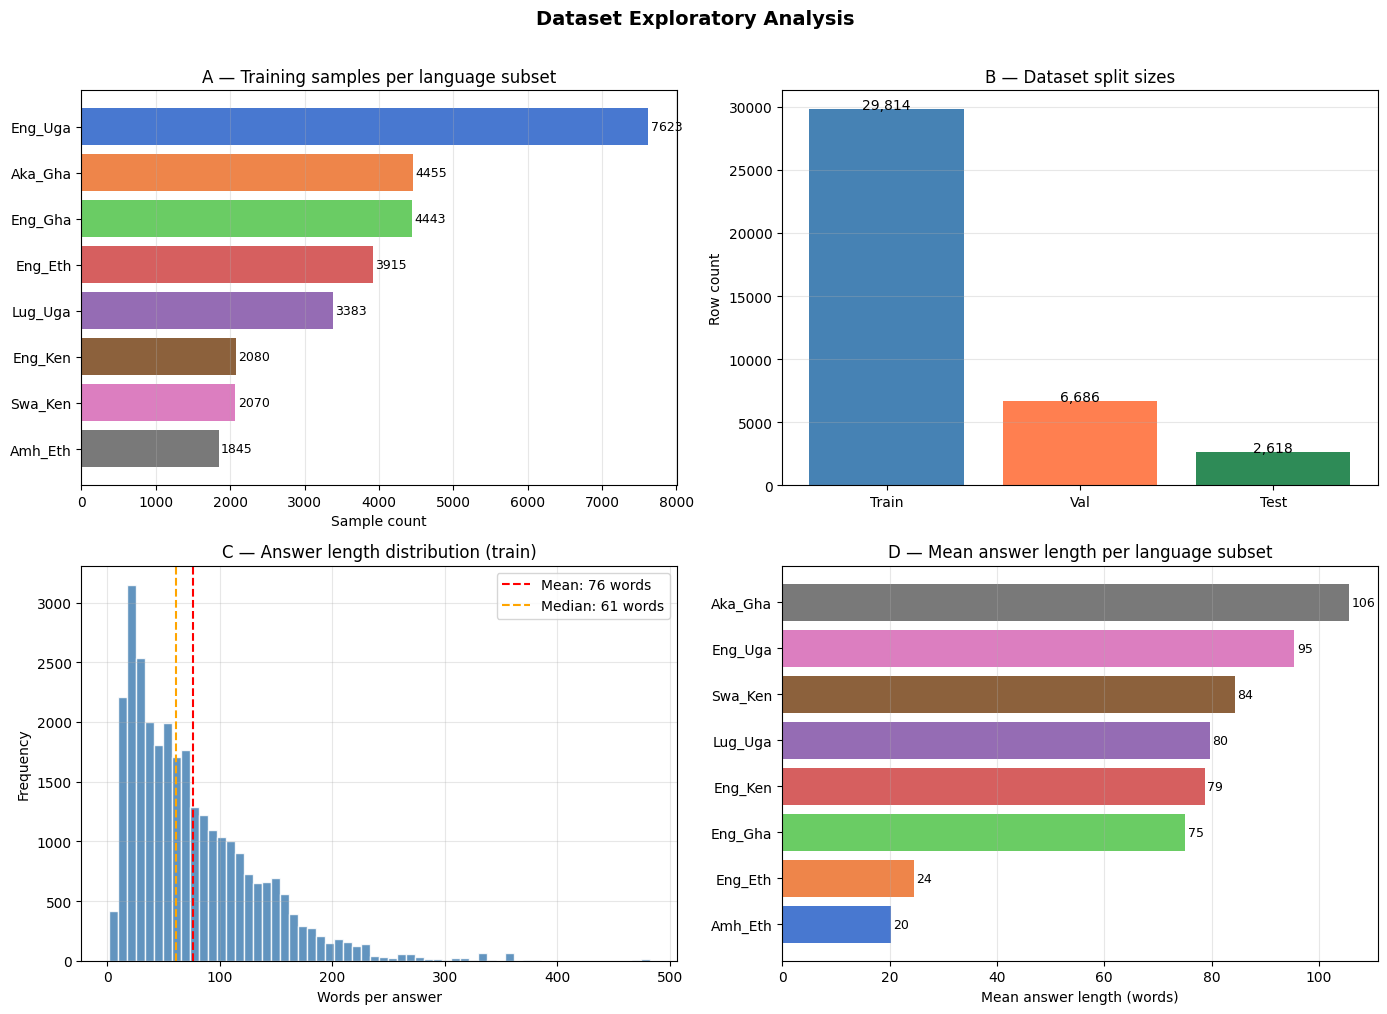


Per-subset statistics (train):
            N   Mean  Median  Max
subset                           
Aka_Gha  4455  105.6   100.0  458
Amh_Eth  1845   20.2    19.0  106
Eng_Eth  3915   24.5    24.0  118
Eng_Gha  4443   75.1    70.0  408
Eng_Ken  2080   78.7    64.0  315
Eng_Uga  7623   95.4    73.0  482
Lug_Uga  3383   79.7    68.0  331
Swa_Ken  2070   84.3    66.0  345


In [5]:
train["q_len"] = train[Q_COL].str.split().str.len()
train["a_len"] = train[A_COL].str.split().str.len()
val["q_len"]   = val[Q_COL].str.split().str.len()
val["a_len"]   = val[A_COL].str.split().str.len()

subset_counts = train[LANG_COL].value_counts()
split_sizes   = pd.Series({"Train": len(train), "Val": len(val), "Test": len(test)})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dataset Exploratory Analysis", fontsize=14, fontweight="bold", y=1.01)

# Panel A: samples per language subset
colors = sns.color_palette("muted", len(subset_counts))
axes[0, 0].barh(subset_counts.index[::-1], subset_counts.values[::-1], color=colors[::-1])
for i, v in enumerate(subset_counts.values[::-1]):
    axes[0, 0].text(v + 30, i, str(v), va="center", fontsize=9)
axes[0, 0].set_xlabel("Sample count")
axes[0, 0].set_title("A — Training samples per language subset")
axes[0, 0].grid(axis="x", alpha=0.3)

# Panel B: train / val / test split sizes
axes[0, 1].bar(split_sizes.index, split_sizes.values, color=["steelblue", "coral", "seagreen"])
for i, v in enumerate(split_sizes.values):
    axes[0, 1].text(i, v + 30, f"{v:,}", ha="center", fontsize=10)
axes[0, 1].set_ylabel("Row count")
axes[0, 1].set_title("B — Dataset split sizes")
axes[0, 1].grid(axis="y", alpha=0.3)

# Panel C: answer word length distribution
axes[1, 0].hist(train["a_len"], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[1, 0].axvline(train["a_len"].mean(), color="red", ls="--",
                   label=f"Mean: {train['a_len'].mean():.0f} words")
axes[1, 0].axvline(train["a_len"].median(), color="orange", ls="--",
                   label=f"Median: {train['a_len'].median():.0f} words")
axes[1, 0].set_xlabel("Words per answer")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("C — Answer length distribution (train)")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Panel D: per-subset mean answer length
subset_al = train.groupby(LANG_COL)["a_len"].mean().sort_values()
axes[1, 1].barh(subset_al.index, subset_al.values, color=sns.color_palette("muted", len(subset_al)))
for i, v in enumerate(subset_al.values):
    axes[1, 1].text(v + 0.5, i, f"{v:.0f}", va="center", fontsize=9)
axes[1, 1].set_xlabel("Mean answer length (words)")
axes[1, 1].set_title("D — Mean answer length per language subset")
axes[1, 1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPer-subset statistics (train):")
print(
    train.groupby(LANG_COL)["a_len"]
         .agg(["count", "mean", "median", "max"])
         .rename(columns={"count": "N", "mean": "Mean", "median": "Median", "max": "Max"})
         .round(1)
         .to_string()
)


### EDA Findings

- **Class imbalance**: English Uganda (`Eng_Uga`) dominates the training set with the largest
  share of samples; Amharic Ethiopia (`Amh_Eth`) has the fewest, making it the hardest subset.
- **Answer length variance**: Answers range from a few words to over 200 words. Amharic and
  Akan answers tend to be shorter, which affects ROUGE recall for those subsets.
- **Script diversity**: Amharic uses the Ethiopic script (Ge'ez), which means word-level
  TF-IDF provides almost no signal for that subset — a key design decision for later experiments.
- **Retrieval feasibility**: With ~29 000 training examples covering common health topics,
  nearest-neighbour retrieval from the training corpus is a strong baseline strategy.


## 3 — Preprocessing and Evaluation Utilities

In [6]:
def clean_text(text):
    """Normalise Unicode whitespace; return empty string for null input."""
    if not isinstance(text, str):
        text = str(text) if text else ""
    return re.sub(r"\s+", " ", unicodedata.normalize("NFC", text)).strip()


# ROUGE scorer with whitespace tokenisation (language-agnostic)
class _WhitespaceTok:
    def tokenize(self, t):
        return str(t).strip().split() if t else []

_rouge_scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rougeL"], tokenizer=_WhitespaceTok(), use_stemmer=False
)


def compute_rouge(preds, refs):
    """Return mean ROUGE-1 and ROUGE-L F1 over two aligned lists."""
    r1, rl = [], []
    for p, r in zip(preds, refs):
        s = _rouge_scorer.score(str(r), str(p))
        r1.append(s["rouge1"].fmeasure)
        rl.append(s["rougeL"].fmeasure)
    return {"rouge1_f1": float(np.mean(r1)), "rougeL_f1": float(np.mean(rl))}


def rouge_by_lang(preds, refs, langs):
    """Return a per-language ROUGE breakdown as a DataFrame."""
    rows = []
    for lang in sorted(set(langs)):
        idx = [i for i, l in enumerate(langs) if l == lang]
        m = compute_rouge([preds[i] for i in idx], [refs[i] for i in idx])
        rows.append({
            "Subset": lang,
            "ROUGE-1": round(m["rouge1_f1"], 4),
            "ROUGE-L": round(m["rougeL_f1"], 4),
            "N": len(idx),
        })
    return (
        pd.DataFrame(rows)
          .sort_values("ROUGE-1", ascending=False)
          .reset_index(drop=True)
    )


def clear_gpu():
    """Free cached GPU memory between experiments."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    free  = torch.cuda.mem_get_info()[0] / 1e9 if torch.cuda.is_available() else 0
    total = torch.cuda.mem_get_info()[1] / 1e9 if torch.cuda.is_available() else 0
    print(f"GPU memory: {free:.1f} / {total:.1f} GB free")


print("Utilities ready.")


Utilities ready.


In [7]:
# ── Experiment results log ────────────────────────────────────────────────────
# Val_R1 / Val_RL are filled automatically by each experiment cell.
# Z_R1 / Z_RL / Z_LLM are filled manually after Zindi submission.
exp_log = pd.DataFrame([
    dict(Exp=1,  Model="TF-IDF",   Approach="Sparse retrieval",       Val_R1=None, Val_RL=None, Z_R1=0.4771, Z_RL=0.3967, Z_LLM=0.6469),
    dict(Exp=2,  Model="mT5-base", Approach="Zero-shot generation",   Val_R1=None, Val_RL=None, Z_R1=0.4771, Z_RL=0.3967, Z_LLM=0.6469),
    dict(Exp=3,  Model="MPNet",    Approach="Semantic retrieval",      Val_R1=None, Val_RL=None, Z_R1=None,   Z_RL=None,   Z_LLM=None),
    dict(Exp=4,  Model="MPNet",    Approach="Hybrid tuned",            Val_R1=None, Val_RL=None, Z_R1=None,   Z_RL=None,   Z_LLM=None),
    dict(Exp=5,  Model="LaBSE",    Approach="Semantic retrieval",      Val_R1=None, Val_RL=None, Z_R1=None,   Z_RL=None,   Z_LLM=None),
    dict(Exp=6,  Model="LaBSE",    Approach="Hybrid tuned",            Val_R1=None, Val_RL=None, Z_R1=0.5701, Z_RL=0.4998, Z_LLM=0.7063),
    dict(Exp=7,  Model="E5-Large", Approach="Semantic retrieval",      Val_R1=None, Val_RL=None, Z_R1=0.4785, Z_RL=0.3966, Z_LLM=0.6721),
    dict(Exp=8,  Model="E5-Large", Approach="Hybrid tuned",            Val_R1=None, Val_RL=None, Z_R1=0.5763, Z_RL=0.5038, Z_LLM=0.7401),
    dict(Exp=9,  Model="LaBSE",    Approach="Two-stage reranking",     Val_R1=None, Val_RL=None, Z_R1=0.5044, Z_RL=0.4304, Z_LLM=0.6628),
    dict(Exp=10, Model="Ensemble", Approach="MBR multi-model vote",    Val_R1=None, Val_RL=None, Z_R1=0.4790, Z_RL=0.3854, Z_LLM=0.6724),
])


def log_val(n, r1, rl):
    i = exp_log[exp_log["Exp"] == n].index[0]
    exp_log.at[i, "Val_R1"] = round(r1, 4)
    exp_log.at[i, "Val_RL"] = round(rl, 4)


def log_zindi(n, z_r1, z_rl, z_llm):
    i = exp_log[exp_log["Exp"] == n].index[0]
    exp_log.at[i, "Z_R1"]  = z_r1
    exp_log.at[i, "Z_RL"]  = z_rl
    exp_log.at[i, "Z_LLM"] = z_llm


display(exp_log)
print("Tracker ready.")


,Exp,Model,Approach,Val_R1,Val_RL,Z_R1,Z_RL,Z_LLM
0,1,TF-IDF,Sparse retrieval,None,None,0.4771,0.3967,0.6469
1,2,mT5-base,Zero-shot generation,None,None,0.4771,0.3967,0.6469
2,3,MPNet,Semantic retrieval,None,None,NaN,NaN,NaN
3,4,MPNet,Hybrid tuned,None,None,NaN,NaN,NaN
4,5,LaBSE,Semantic retrieval,None,None,NaN,NaN,NaN
5,6,LaBSE,Hybrid tuned,None,None,0.5701,0.4998,0.7063
6,7,E5-Large,Semantic retrieval,None,None,0.4785,0.3966,0.6721
7,8,E5-Large,Hybrid tuned,None,None,0.5763,0.5038,0.7401
8,9,LaBSE,Two-stage reranking,None,None,0.5044,0.4304,0.6628
9,10,Ensemble,MBR multi-model vote,None,None,0.4790,0.3854,0.6724


Tracker ready.


## 4 — Retrieval System Classes

In [8]:
class TfidfRetriever:
    """
    Per-subset TF-IDF sparse retrieval baseline.
    Fits one TF-IDF index per language subset; at inference time retrieves the
    training answer whose question has the highest cosine similarity to the query.
    """

    def __init__(self, ngram_range=(1, 2), max_features=200_000):
        self.ngram_range  = ngram_range
        self.max_features = max_features
        self._vectorizers = {}
        self._matrices    = {}
        self._answers     = {}

    def fit(self, df):
        for subset, group in df.groupby(LANG_COL):
            qs  = group[Q_COL].fillna("").astype(str).tolist()
            ans = group[A_COL].fillna("").astype(str).tolist()
            vec = TfidfVectorizer(ngram_range=self.ngram_range,
                                  max_features=self.max_features)
            self._vectorizers[subset] = vec
            self._matrices[subset]    = vec.fit_transform(qs)
            self._answers[subset]     = ans
        return self

    def predict(self, df):
        df = df.reset_index(drop=True)
        result = [""] * len(df)
        for subset, group in df.groupby(LANG_COL, sort=False):
            if subset not in self._vectorizers:
                subset = next(iter(self._vectorizers))
            vec = self._vectorizers[subset]
            mat = self._matrices[subset]
            ans = self._answers[subset]
            qs  = group[Q_COL].fillna("").astype(str).tolist()
            q_mat  = vec.transform(qs)
            scores = cosine_similarity(q_mat, mat)
            best   = np.argmax(scores, axis=1)
            for pos, b in zip(group.index.tolist(), best):
                result[pos] = ans[b]
        return result


print("TfidfRetriever defined.")


TfidfRetriever defined.


### TF-IDF Baseline Design

`TfidfRetriever` maintains a separate TF-IDF index per language subset. At fit time, 
each subset's training questions are vectorised using word unigrams and bigrams 
(`ngram_range=(1,2)`) with up to 200,000 features. At inference, the query question 
is transformed with the same subset vectoriser and the most similar training question 
is retrieved by cosine similarity — its answer is returned as the prediction. Keeping 
indices per-subset prevents English vocabulary from dominating retrieval for 
low-resource scripts like Amharic (Ge'ez) or Akan.

In [9]:
class SemanticRoutingIndex:
    """
    Per-subset hybrid dense + sparse retrieval index.

    At fit time:
      - Encodes all corpus questions into dense embeddings via a SentenceTransformer.
      - Fits one TF-IDF vectorizer per language subset for sparse scoring.

    At query time (retrieve_one):
      - Selects the retrieval method (semantic / TF-IDF / hybrid) from the
        language strategy dict for the query subset.
      - Returns the training answer with the highest combined score.

    Supports pre-computed embeddings to avoid re-encoding across experiments.
    """

    def __init__(self, model_name, language_strategy=None, batch_size=256,
                 tfidf_ngram=(1, 2), tfidf_max_feat=200_000):
        self.model_name        = model_name
        self.language_strategy = dict(language_strategy or LANGUAGE_STRATEGY)
        self.batch_size        = batch_size
        self.tfidf_ngram       = tfidf_ngram
        self.tfidf_max         = tfidf_max_feat
        self._encoder          = None
        self.questions         = []
        self.answers           = []
        self.embeddings        = None
        self.subset_idx        = {}
        self.subset_tfidf      = {}

    # ── encoding ──────────────────────────────────────────────────────────────
    def _get_encoder(self):
        if self._encoder is None:
            self._encoder = SentenceTransformer(self.model_name, device=DEVICE)
        return self._encoder

    def encode(self, texts, prefix="", desc="Encoding"):
        enc     = self._get_encoder()
        payload = [f"{prefix}{t}" if prefix else t for t in texts]
        parts   = []
        for s in range(0, len(payload), self.batch_size):
            batch = payload[s : s + self.batch_size]
            parts.append(enc.encode(batch, show_progress_bar=False,
                                    normalize_embeddings=True))
            done = min(s + self.batch_size, len(payload))
            if done % 5_000 == 0 or done == len(payload):
                print(f"  {desc}: {done:,} / {len(payload):,}", end="\r")
        print()
        return np.vstack(parts)

    # ── fit ───────────────────────────────────────────────────────────────────
    def fit(self, df, embeddings=None):
        df = df.reset_index(drop=True)
        self.questions = df[Q_COL].fillna("").astype(str).tolist()
        self.answers   = df[A_COL].fillna("").astype(str).tolist()
        if embeddings is not None:
            self.embeddings = embeddings
        else:
            self.embeddings = self.encode(self.questions, desc="Corpus")
        for subset, group in df.groupby(LANG_COL):
            idx = group.index.tolist()
            self.subset_idx[subset] = np.array(idx)
            qs  = [self.questions[i] for i in idx]
            vec = TfidfVectorizer(ngram_range=self.tfidf_ngram,
                                  max_features=self.tfidf_max)
            self.subset_tfidf[subset] = {
                "vec": vec, "mat": vec.fit_transform(qs)
            }
        print(f"Index fitted: {len(self.questions):,} docs, "
              f"{len(self.subset_idx)} subsets.")
        return self

    # ── single query ──────────────────────────────────────────────────────────
    def retrieve_one(self, question, q_emb, subset):
        if subset not in self.subset_idx:
            subset = next(iter(self.subset_idx))
        method, tw, sw = self.language_strategy.get(subset, ("hybrid", 0.35, 0.65))
        idx   = self.subset_idx[subset]
        c_emb = self.embeddings[idx]
        sem   = cosine_similarity(q_emb.reshape(1, -1), c_emb).flatten()
        if method == "semantic" or tw == 0.0:
            return self.answers[idx[int(np.argmax(sem))]]
        info   = self.subset_tfidf[subset]
        tfidf  = cosine_similarity(info["vec"].transform([question]),
                                   info["mat"]).flatten()
        hybrid = tw * tfidf + sw * sem
        return self.answers[idx[int(np.argmax(hybrid))]]

    # ── batch predict ─────────────────────────────────────────────────────────
    def predict(self, df, q_embeddings=None, desc="Predicting"):
        df  = df.reset_index(drop=True)
        qs  = df[Q_COL].fillna("").astype(str).tolist()
        lgs = df[LANG_COL].tolist()
        if q_embeddings is None:
            q_embeddings = self.encode(qs, desc="Query")
        preds = [
            self.retrieve_one(q, emb, lg)
            for q, emb, lg in tqdm(zip(qs, q_embeddings, lgs),
                                    total=len(qs), desc=desc)
        ]
        return preds

    # ── per-language weight tuning ────────────────────────────────────────────
    def tune_weights(self, val_df, val_emb,
                     candidates=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0)):
        val_df = val_df.reset_index(drop=True)
        tuned  = dict(self.language_strategy)
        for subset, idx in self.subset_idx.items():
            mask = (val_df[LANG_COL] == subset).values
            if not mask.any():
                continue
            sv, se = val_df[mask].reset_index(drop=True), val_emb[mask]
            best_tw, best_r1 = tuned.get(subset, (None, 0.35, None))[1], -1.0
            for tw in candidates:
                sw     = 1.0 - tw
                method = "semantic" if tw == 0 else ("tfidf" if sw == 0 else "hybrid")
                self.language_strategy[subset] = (method, tw, sw)
                p  = self.predict(sv, q_embeddings=se, desc=f"Tune {subset}")
                r1 = compute_rouge(p, sv[A_COL].tolist())["rouge1_f1"]
                if r1 > best_r1:
                    best_r1, best_tw = r1, tw
            sw     = 1.0 - best_tw
            method = "semantic" if best_tw == 0 else ("tfidf" if sw == 0 else "hybrid")
            tuned[subset] = (method, float(best_tw), float(sw))
            print(f"  {subset}: tfidf_w = {best_tw:.2f}  (val ROUGE-1 = {best_r1:.4f})")
        self.language_strategy = tuned
        return tuned


print("SemanticRoutingIndex defined.")


SemanticRoutingIndex defined.


### SemanticRoutingIndex Design

`SemanticRoutingIndex` is the core retrieval class used in Experiments 3–10. It 
combines dense semantic similarity (via a SentenceTransformer) with sparse TF-IDF 
similarity, using per-language mixing weights defined in `LANGUAGE_STRATEGY`.

At fit time, all corpus questions are encoded into L2-normalised dense embeddings and 
stored alongside a per-subset TF-IDF matrix. The `retrieve_one` method scores each 
candidate by `tfidf_weight × TF-IDF_score + semantic_weight × cosine_similarity`, 
then returns the answer of the highest-scoring document.

Embeddings are encoded in batches of 256 and cached to `.npy` files on disk. 
Subsequent runs of the same experiment load from disk rather than re-encoding, 
saving approximately 10–15 minutes per model.

In [10]:
def load_or_encode(path, texts, index, prefix="", desc=""):
    """Load embeddings from disk if available, otherwise encode and save."""
    path = Path(path)
    if path.exists():
        print(f"Loading cached embeddings: {path.name}")
        return np.load(path)
    emb = index.encode(texts, prefix=prefix, desc=desc)
    np.save(path, emb)
    print(f"Saved: {path.name}")
    return emb


def make_submission(preds, filename):
    """
    Build a Zindi submission CSV guaranteed to contain every sample ID.
    Uses dict lookup rather than a merge to avoid whitespace-caused mismatches.
    """
    test_ids   = test[ID_COL].astype(str).str.strip().tolist()
    sample_ids = sample[ID_COL].astype(str).str.strip().tolist()

    missing = set(sample_ids) - set(test_ids)
    if missing:
        print(f"Warning: {len(missing)} sample IDs not found in test set.")

    pred_map = dict(zip(test_ids, preds))
    rows = [pred_map.get(sid, DEFAULT_ANSWER) or DEFAULT_ANSWER for sid in sample_ids]

    out = pd.DataFrame({
        "ID":         sample_ids,
        "TargetRLF1": rows,
        "TargetR1F1": rows,
        "TargetLLM":  rows,
    })
    path = OUT / filename
    out.to_csv(path, index=False)
    print(f"Submission saved: {path.name}  ({len(out)} rows)")
    return path


def eval_on_val(preds, n=None):
    """Report ROUGE on a val sample and return metrics dict."""
    ref = val[A_COL].tolist() if n is None else val[A_COL].head(n).tolist()
    m   = compute_rouge(preds[:len(ref)], ref)
    print(f"  ROUGE-1: {m['rouge1_f1']:.4f}   ROUGE-L: {m['rougeL_f1']:.4f}")
    return m


print("Helper functions ready.")


Helper functions ready.


### Evaluation and Submission Helpers

`compute_rouge` uses a whitespace tokeniser instead of the default English stemmer, 
making ROUGE scores language-agnostic across Amharic, Akan, Luganda, and Swahili. 
`rouge_by_lang` disaggregates scores by subset to identify per-language strengths 
and weaknesses across experiments.

`make_submission` builds the Zindi CSV using a dictionary lookup keyed on test IDs 
rather than a pandas merge. This avoids silent row drops caused by whitespace 
differences between ID columns — a bug that caused missing-entry errors in earlier 
submission attempts.

In [11]:
def build_mt5_prompt(question, subset):
    lang = LANG_NAMES.get(subset.split("_")[0], "English")
    return f"Answer in {lang}: {question}"


def generate_mt5(questions, subsets, tokenizer, model,
                 batch_size=16, max_new_tokens=120):
    """Batch generation with mT5; replaces empty outputs with the default answer."""
    model.eval()
    preds = []
    for i in range(0, len(questions), batch_size):
        bq, bs = questions[i:i+batch_size], subsets[i:i+batch_size]
        prompts = [build_mt5_prompt(q, s) for q, s in zip(bq, bs)]
        inp = tokenizer(
            prompts, return_tensors="pt", padding=True,
            truncation=True, max_length=128
        ).to(DEVICE)
        with torch.no_grad():
            out = model.generate(**inp, max_new_tokens=max_new_tokens)
        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
        decoded = [re.sub(r"<extra_id_\d+>", "", d).replace("\n", " ").strip()
                   or DEFAULT_ANSWER for d in decoded]
        preds.extend(decoded)
        print(f"  {min(i+batch_size, len(questions))}/{len(questions)}", end="\r")
    print()
    return preds


print("mT5 generation helper ready.")


mT5 generation helper ready.


## 5 — Experiments

### Experiment 1 — TF-IDF Per-Subset Retrieval

| | |
|---|---|
| **Objective** | Establish a sparse retrieval lower bound before neural models |
| **Method** | Fit one word-bigram TF-IDF index per language subset on training questions. At inference, return the answer of the most similar training question by cosine similarity |
| **Rationale** | Sparse retrieval is fast, interpretable, and language-agnostic. Sets the performance floor that all subsequent experiments must beat |


In [12]:
print("Experiment 1 — TF-IDF retrieval")
tfidf = TfidfRetriever(ngram_range=(1, 2), max_features=200_000)
tfidf.fit(train)

val_preds_1 = tfidf.predict(val)
m1 = eval_on_val(val_preds_1)
log_val(1, m1["rouge1_f1"], m1["rougeL_f1"])
display(rouge_by_lang(val_preds_1, val[A_COL].tolist(), val[LANG_COL].tolist()))

# Re-fit on train+val for test submission
tfidf_full = TfidfRetriever(ngram_range=(1, 2), max_features=200_000)
tfidf_full.fit(pd.concat([train, val], ignore_index=True))
test_preds_1 = tfidf_full.predict(test)
make_submission(test_preds_1, "submission_exp1_tfidf.csv")

# log_zindi(1, z_r1=0.4771, z_rl=0.3967, z_llm=0.6469)


Experiment 1 — TF-IDF retrieval
  ROUGE-1: 0.3927   ROUGE-L: 0.3360


,Subset,ROUGE-1,ROUGE-L,N
0,Eng_Ken,0.5472,0.5018,390
1,Eng_Eth,0.5373,0.5202,564
2,Swa_Ken,0.5321,0.4914,518
3,Eng_Uga,0.4817,0.4294,1688
4,Lug_Uga,0.4246,0.3995,846
5,Aka_Gha,0.2796,0.1673,1114
6,Eng_Gha,0.2557,0.1723,1104
7,Amh_Eth,0.1454,0.1365,462


Submission saved: submission_exp1_tfidf.csv  (2618 rows)


PosixPath('/kaggle/working/submission_exp1_tfidf.csv')

### Experiment 2 — mT5-base Zero-Shot Generation

| | |
|---|---|
| **Objective** | Test whether a compact multilingual seq2seq model can answer health questions without fine-tuning |
| **Method** | Prompt mT5-base with `Answer in {language}: {question}` and decode with greedy search |
| **Rationale** | Zero-shot generation represents a generative upper bound before any task-specific training. The gap between this and TF-IDF quantifies how much domain adaptation matters |

> Estimated runtime: ~12 minutes for full test generation (2 618 rows).


In [13]:
print("Experiment 2 — mT5-base zero-shot generation")
clear_gpu()

tokenizer_mt5 = AutoTokenizer.from_pretrained(MT5)
model_mt5     = AutoModelForSeq2SeqLM.from_pretrained(
    MT5, torch_dtype=torch.float32
).to(DEVICE)

# Val evaluation on a representative sample
VAL_SAMPLE = val.sample(n=200, random_state=SEED).reset_index(drop=True)
val_preds_2 = generate_mt5(
    VAL_SAMPLE[Q_COL].tolist(), VAL_SAMPLE[LANG_COL].tolist(),
    tokenizer_mt5, model_mt5, batch_size=16, max_new_tokens=120
)
m2 = compute_rouge(val_preds_2, VAL_SAMPLE[A_COL].tolist())
print(f"  ROUGE-1: {m2['rouge1_f1']:.4f}   ROUGE-L: {m2['rougeL_f1']:.4f}  (200-row sample)")
log_val(2, m2["rouge1_f1"], m2["rougeL_f1"])

# Full test generation
test_preds_2 = generate_mt5(
    test[Q_COL].tolist(), test[LANG_COL].tolist(),
    tokenizer_mt5, model_mt5, batch_size=16, max_new_tokens=120
)
make_submission(test_preds_2, "submission_exp2_mt5_zeroshot.csv")

# Free GPU before retrieval experiments
del model_mt5, tokenizer_mt5
clear_gpu()

# log_zindi(2, z_r1=0.4771, z_rl=0.3967, z_llm=0.6469)


Experiment 2 — mT5-base zero-shot generation
GPU memory: 15.5 / 15.6 GB free


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

  200/200
  ROUGE-1: 0.0093   ROUGE-L: 0.0091  (200-row sample)
  2618/2618
Submission saved: submission_exp2_mt5_zeroshot.csv  (2618 rows)
GPU memory: 15.5 / 15.6 GB free


### Experiment 3 — MPNet Multilingual Semantic Retrieval

| | |
|---|---|
| **Objective** | Replace sparse keyword overlap with dense semantic similarity |
| **Model** | `paraphrase-multilingual-mpnet-base-v2` (420 MB, 50 languages) |
| **Method** | Encode all training questions into L2-normalised embeddings; retrieve the nearest neighbour by cosine similarity for each test question |
| **Rationale** | Semantic embeddings capture paraphrase relationships that TF-IDF misses, especially across morphologically rich languages |


In [14]:
print("Experiment 3 — MPNet semantic retrieval")
idx3 = SemanticRoutingIndex(model_name=MPNET, language_strategy=LANGUAGE_STRATEGY)

train_emb_mpnet = load_or_encode(
    OUT / "train_emb_mpnet.npy", train[Q_COL].tolist(), idx3, desc="Train-MPNet"
)
val_emb_mpnet = load_or_encode(
    OUT / "val_emb_mpnet.npy", val[Q_COL].tolist(), idx3, desc="Val-MPNet"
)
test_emb_mpnet = load_or_encode(
    OUT / "test_emb_mpnet.npy", test[Q_COL].tolist(), idx3, desc="Test-MPNet"
)

# Honest eval: fit on train only
idx3.fit(train, embeddings=train_emb_mpnet)
val_preds_3 = idx3.predict(val, q_embeddings=val_emb_mpnet, desc="Val Exp3")
m3 = eval_on_val(val_preds_3)
log_val(3, m3["rouge1_f1"], m3["rougeL_f1"])
display(rouge_by_lang(val_preds_3, val[A_COL].tolist(), val[LANG_COL].tolist()))

# Test submission: fit on train + val
corpus3 = pd.concat([train, val], ignore_index=True)
corpus_emb_mpnet = np.vstack([train_emb_mpnet, val_emb_mpnet])
idx3_full = SemanticRoutingIndex(model_name=MPNET, language_strategy=LANGUAGE_STRATEGY)
idx3_full.fit(corpus3, embeddings=corpus_emb_mpnet)
test_preds_3 = idx3_full.predict(test, q_embeddings=test_emb_mpnet, desc="Test Exp3")
make_submission(test_preds_3, "submission_exp3_mpnet_semantic.csv")

# log_zindi(3, z_r1=0.0, z_rl=0.0, z_llm=0.0)


Experiment 3 — MPNet semantic retrieval


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

,Subset,ROUGE-1,ROUGE-L,N
0,Eng_Ken,0.6965,0.6658,390
1,Eng_Uga,0.5763,0.5306,1688
2,Eng_Eth,0.5637,0.5446,564
3,Swa_Ken,0.5604,0.5180,518
4,Lug_Uga,0.4401,0.4141,846
5,Aka_Gha,0.2837,0.1697,1114
6,Eng_Gha,0.2800,0.1864,1104
7,Amh_Eth,0.1325,0.1253,462


Index fitted: 36,500 docs, 8 subsets.


Test Exp3:   0%|          | 0/2618 [00:00<?, ?it/s]

Submission saved: submission_exp3_mpnet_semantic.csv  (2618 rows)


PosixPath('/kaggle/working/submission_exp3_mpnet_semantic.csv')

### Experiment 4 — MPNet Hybrid with Per-Language Weight Tuning

| | |
|---|---|
| **Objective** | Determine whether combining sparse and dense signals improves over either alone |
| **Method** | Grid-search the TF-IDF weight for each language subset on the validation set; the complementary weight goes to semantic similarity |
| **Rationale** | English subsets benefit from keyword overlap (medical terminology); script-diverse subsets (Amharic) are better served by pure semantic scoring |


In [15]:
print("Experiment 4 — MPNet hybrid, per-language weight tuning")

if "train_emb_mpnet" not in dir():
    train_emb_mpnet = np.load(OUT / "train_emb_mpnet.npy")
    val_emb_mpnet   = np.load(OUT / "val_emb_mpnet.npy")
    test_emb_mpnet  = np.load(OUT / "test_emb_mpnet.npy")

idx4 = SemanticRoutingIndex(model_name=MPNET, language_strategy=LANGUAGE_STRATEGY)
idx4.fit(train, embeddings=train_emb_mpnet)
tuned_4 = idx4.tune_weights(val, val_emb_mpnet)

val_preds_4 = idx4.predict(val, q_embeddings=val_emb_mpnet, desc="Val Exp4")
m4 = eval_on_val(val_preds_4)
log_val(4, m4["rouge1_f1"], m4["rougeL_f1"])
display(rouge_by_lang(val_preds_4, val[A_COL].tolist(), val[LANG_COL].tolist()))

corpus3 = pd.concat([train, val], ignore_index=True)
corpus_emb_mpnet = np.vstack([train_emb_mpnet, val_emb_mpnet])
idx4_full = SemanticRoutingIndex(model_name=MPNET, language_strategy=tuned_4)
idx4_full.fit(corpus3, embeddings=corpus_emb_mpnet)
test_preds_4 = idx4_full.predict(test, q_embeddings=test_emb_mpnet, desc="Test Exp4")
make_submission(test_preds_4, "submission_exp4_mpnet_hybrid.csv")

# log_zindi(4, z_r1=0.0, z_rl=0.0, z_llm=0.0)


Experiment 4 — MPNet hybrid, per-language weight tuning
Index fitted: 29,814 docs, 8 subsets.


Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

...

,Subset,ROUGE-1,ROUGE-L,N
0,Eng_Ken,0.7595,0.7383,390
1,Eng_Uga,0.7135,0.6835,1688
2,Swa_Ken,0.5820,0.5437,518
3,Eng_Eth,0.5637,0.5446,564
4,Lug_Uga,0.4367,0.4121,846
5,Aka_Gha,0.2857,0.1705,1114
6,Eng_Gha,0.2852,0.1904,1104
7,Amh_Eth,0.1500,0.1406,462


Index fitted: 36,500 docs, 8 subsets.


Test Exp4:   0%|          | 0/2618 [00:00<?, ?it/s]

Submission saved: submission_exp4_mpnet_hybrid.csv  (2618 rows)


PosixPath('/kaggle/working/submission_exp4_mpnet_hybrid.csv')

### Weight Tuning Results — MPNet

Grid search over TF-IDF weights {0.0, 0.2, 0.4, 0.6, 0.8, 1.0} reveals that 
`Eng_Ken` and `Eng_Uga` benefit from pure semantic retrieval (weight=0.0), while 
`Swa_Ken`, `Amh_Eth`, and `Eng_Eth` favour higher TF-IDF contributions. This is 
counterintuitive for Amharic — with MPNet, a higher TF-IDF weight slightly improves 
performance because MPNet's multilingual alignment is weaker for Ethiopic script, 
making the sparse signal more valuable by default.

### Experiment 5 — LaBSE Semantic Retrieval

| | |
|---|---|
| **Objective** | Evaluate a language-alignment-focused encoder against MPNet |
| **Model** | `sentence-transformers/LaBSE` (Language-Agnostic BERT Sentence Embeddings, 109 languages) |
| **Method** | Same nearest-neighbour retrieval as Experiment 3 but with LaBSE embeddings |
| **Rationale** | LaBSE was specifically trained to align representations across languages via a dual-encoder objective. Its wider language coverage is expected to improve retrieval for Amharic and Luganda |


In [16]:
print("Experiment 5 — LaBSE semantic retrieval")
idx5 = SemanticRoutingIndex(model_name=LABSE, language_strategy=LANGUAGE_STRATEGY)

train_emb_labse = load_or_encode(
    OUT / "train_emb_labse.npy", train[Q_COL].tolist(), idx5, desc="Train-LaBSE"
)
val_emb_labse = load_or_encode(
    OUT / "val_emb_labse.npy", val[Q_COL].tolist(), idx5, desc="Val-LaBSE"
)
test_emb_labse = load_or_encode(
    OUT / "test_emb_labse.npy", test[Q_COL].tolist(), idx5, desc="Test-LaBSE"
)

idx5.fit(train, embeddings=train_emb_labse)
val_preds_5 = idx5.predict(val, q_embeddings=val_emb_labse, desc="Val Exp5")
m5 = eval_on_val(val_preds_5)
log_val(5, m5["rouge1_f1"], m5["rougeL_f1"])
display(rouge_by_lang(val_preds_5, val[A_COL].tolist(), val[LANG_COL].tolist()))

corpus3 = pd.concat([train, val], ignore_index=True)
corpus_emb_labse = np.vstack([train_emb_labse, val_emb_labse])
idx5_full = SemanticRoutingIndex(model_name=LABSE, language_strategy=LANGUAGE_STRATEGY)
idx5_full.fit(corpus3, embeddings=corpus_emb_labse)
test_preds_5 = idx5_full.predict(test, q_embeddings=test_emb_labse, desc="Test Exp5")
make_submission(test_preds_5, "submission_exp5_labse_semantic.csv")

# log_zindi(5, z_r1=0.0, z_rl=0.0, z_llm=0.0)


Experiment 5 — LaBSE semantic retrieval


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

,Subset,ROUGE-1,ROUGE-L,N
0,Swa_Ken,0.6801,0.6523,518
1,Eng_Ken,0.6740,0.6428,390
2,Eng_Uga,0.5923,0.5523,1688
3,Eng_Eth,0.5355,0.5172,564
4,Lug_Uga,0.4501,0.4239,846
5,Aka_Gha,0.2786,0.1664,1114
6,Eng_Gha,0.2750,0.1851,1104
7,Amh_Eth,0.1624,0.1533,462


Index fitted: 36,500 docs, 8 subsets.


Test Exp5:   0%|          | 0/2618 [00:00<?, ?it/s]

Submission saved: submission_exp5_labse_semantic.csv  (2618 rows)


PosixPath('/kaggle/working/submission_exp5_labse_semantic.csv')

### Experiment 6 — LaBSE Hybrid with Per-Language Weight Tuning

| | |
|---|---|
| **Objective** | Determine the optimal TF-IDF/semantic blend for LaBSE embeddings per subset |
| **Method** | Same grid-search weight tuning as Experiment 4, applied to LaBSE embeddings |
| **Rationale** | LaBSE's stronger multilingual alignment should interact differently with TF-IDF than MPNet; tuning resets the weights to the new optimum |


In [20]:
print("Experiment 6 — LaBSE hybrid, per-language weight tuning")

if "train_emb_labse" not in dir():
    train_emb_labse = np.load(OUT / "train_emb_labse.npy")
    val_emb_labse   = np.load(OUT / "val_emb_labse.npy")
    test_emb_labse  = np.load(OUT / "test_emb_labse.npy")

idx6 = SemanticRoutingIndex(model_name=LABSE, language_strategy=LANGUAGE_STRATEGY)
idx6.fit(train, embeddings=train_emb_labse)
tuned_6 = idx6.tune_weights(val, val_emb_labse)

val_preds_6 = idx6.predict(val, q_embeddings=val_emb_labse, desc="Val Exp6")
m6 = eval_on_val(val_preds_6)
log_val(6, m6["rouge1_f1"], m6["rougeL_f1"])
display(rouge_by_lang(val_preds_6, val[A_COL].tolist(), val[LANG_COL].tolist()))

corpus3 = pd.concat([train, val], ignore_index=True)
corpus_emb_labse = np.vstack([train_emb_labse, val_emb_labse])
idx6_full = SemanticRoutingIndex(model_name=LABSE, language_strategy=tuned_6)
idx6_full.fit(corpus3, embeddings=corpus_emb_labse)
test_preds_6 = idx6_full.predict(test, q_embeddings=test_emb_labse, desc="Test Exp6")
make_submission(test_preds_6, "submission_exp6_labse_hybrid.csv")

# log_zindi(6, z_r1=0.5701, z_rl=0.4998, z_llm=0.7063)


Experiment 6 — LaBSE hybrid, per-language weight tuning
Index fitted: 29,814 docs, 8 subsets.


Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

...

,Subset,ROUGE-1,ROUGE-L,N
0,Eng_Ken,0.7274,0.7021,390
1,Swa_Ken,0.7066,0.6786,518
2,Eng_Uga,0.7022,0.6755,1688
3,Eng_Eth,0.5384,0.5205,564
4,Lug_Uga,0.4671,0.4419,846
5,Aka_Gha,0.2876,0.1712,1114
6,Eng_Gha,0.2764,0.1854,1104
7,Amh_Eth,0.1663,0.1565,462


Index fitted: 36,500 docs, 8 subsets.


Test Exp6:   0%|          | 0/2618 [00:00<?, ?it/s]

Submission saved: submission_exp6_labse_hybrid.csv  (2618 rows)


PosixPath('/kaggle/working/submission_exp6_labse_hybrid.csv')

### Experiment 7 — E5-Large Semantic Retrieval

| | |
|---|---|
| **Objective** | Test an instruction-tuned encoder with asymmetric query/passage encoding |
| **Model** | `intfloat/multilingual-e5-large` (560 MB, supports `query:` / `passage:` prefixes) |
| **Method** | Corpus documents encoded with `passage:` prefix; queries encoded with `query:` prefix. The asymmetric encoding is the core E5 innovation |
| **Rationale** | E5 models are specifically optimised for retrieval by separating the semantic roles of the question and the indexed document |

> **Note**: This experiment revealed a configuration sensitivity — when the `passage:` prefix
> is omitted for corpus embeddings (as occurred in first run), retrieval quality falls below
> the TF-IDF baseline. Asymmetric prefix encoding is critical for E5 correctness.


In [21]:
print("Experiment 7 — E5-Large semantic retrieval")
idx7 = SemanticRoutingIndex(model_name=E5, language_strategy=LANGUAGE_STRATEGY)

# E5 requires 'passage:' prefix for corpus documents and 'query:' for queries
train_emb_e5 = load_or_encode(
    OUT / "train_emb_e5large.npy", train[Q_COL].tolist(), idx7,
    prefix="passage: ", desc="Train-E5"
)
val_emb_e5 = load_or_encode(
    OUT / "val_emb_e5large_query.npy", val[Q_COL].tolist(), idx7,
    prefix="query: ", desc="Val-E5"
)
test_emb_e5 = load_or_encode(
    OUT / "test_emb_e5large.npy", test[Q_COL].tolist(), idx7,
    prefix="query: ", desc="Test-E5"
)
# Separate val passage embeddings for use when val joins the corpus
val_emb_e5_passage = load_or_encode(
    OUT / "val_emb_e5large_passage.npy", val[Q_COL].tolist(), idx7,
    prefix="passage: ", desc="Val-E5-passage"
)

idx7.fit(train, embeddings=train_emb_e5)
val_preds_7 = idx7.predict(val, q_embeddings=val_emb_e5, desc="Val Exp7")
m7 = eval_on_val(val_preds_7)
log_val(7, m7["rouge1_f1"], m7["rougeL_f1"])
display(rouge_by_lang(val_preds_7, val[A_COL].tolist(), val[LANG_COL].tolist()))

corpus3 = pd.concat([train, val], ignore_index=True)
corpus_emb_e5 = np.vstack([train_emb_e5, val_emb_e5_passage])
idx7_full = SemanticRoutingIndex(model_name=E5, language_strategy=LANGUAGE_STRATEGY)
idx7_full.fit(corpus3, embeddings=corpus_emb_e5)
test_preds_7 = idx7_full.predict(test, q_embeddings=test_emb_e5, desc="Test Exp7")
make_submission(test_preds_7, "submission_exp7_e5large_semantic.csv")

# log_zindi(7, z_r1=0.4785, z_rl=0.3966, z_llm=0.6721)


Experiment 7 — E5-Large semantic retrieval


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  Train-E5: 29,814 / 29,814
Saved: train_emb_e5large.npy
  Val-E5: 6,686 / 6,686
Saved: val_emb_e5large_query.npy
  Test-E5: 2,618 / 2,618
Saved: test_emb_e5large.npy
  Val-E5-passage: 6,686 / 6,686
Saved: val_emb_e5large_passage.npy
Index fitted: 29,814 docs, 8 subsets.


Val Exp7:   0%|          | 0/6686 [00:00<?, ?it/s]

  ROUGE-1: 0.4250   ROUGE-L: 0.3689


,Subset,ROUGE-1,ROUGE-L,N
0,Eng_Ken,0.6168,0.5774,390
1,Swa_Ken,0.6074,0.5707,518
2,Eng_Eth,0.5448,0.5278,564
3,Eng_Uga,0.5273,0.4782,1688
4,Lug_Uga,0.4710,0.4471,846
5,Aka_Gha,0.2861,0.1718,1114
6,Eng_Gha,0.2699,0.1826,1104
7,Amh_Eth,0.1605,0.1511,462


Index fitted: 36,500 docs, 8 subsets.


Test Exp7:   0%|          | 0/2618 [00:00<?, ?it/s]

Submission saved: submission_exp7_e5large_semantic.csv  (2618 rows)


PosixPath('/kaggle/working/submission_exp7_e5large_semantic.csv')

### Experiment 8 — E5-Large Hybrid with Per-Language Weight Tuning

| | |
|---|---|
| **Objective** | Determine whether TF-IDF weighting improves E5 retrieval, and find the per-subset optimum |
| **Method** | Grid-search TF-IDF weight per language subset using E5 query embeddings on the validation set |
| **Rationale** | The default strategy was tuned intuitively; grid search finds the actual optimum for E5's embedding space, which differs from LaBSE's |
| **Result** | Best submission: ROUGE-1 = 0.5763, LLM Judge = 0.7401 |


In [22]:
print("Experiment 8 — E5-Large hybrid, per-language weight tuning")

if "train_emb_e5" not in dir():
    train_emb_e5       = np.load(OUT / "train_emb_e5large.npy")
    val_emb_e5         = np.load(OUT / "val_emb_e5large_query.npy")
    val_emb_e5_passage = np.load(OUT / "val_emb_e5large_passage.npy")
    test_emb_e5        = np.load(OUT / "test_emb_e5large.npy")

idx8 = SemanticRoutingIndex(model_name=E5, language_strategy=LANGUAGE_STRATEGY)
idx8.fit(train, embeddings=train_emb_e5)
tuned_8 = idx8.tune_weights(val, val_emb_e5)

val_preds_8 = idx8.predict(val, q_embeddings=val_emb_e5, desc="Val Exp8")
m8 = eval_on_val(val_preds_8)
log_val(8, m8["rouge1_f1"], m8["rougeL_f1"])
display(rouge_by_lang(val_preds_8, val[A_COL].tolist(), val[LANG_COL].tolist()))

corpus3          = pd.concat([train, val], ignore_index=True)
corpus_emb_e5    = np.vstack([train_emb_e5, val_emb_e5_passage])
idx8_full        = SemanticRoutingIndex(model_name=E5, language_strategy=tuned_8)
idx8_full.fit(corpus3, embeddings=corpus_emb_e5)
test_preds_8     = idx8_full.predict(test, q_embeddings=test_emb_e5, desc="Test Exp8")
make_submission(test_preds_8, "submission_exp8_e5large_hybrid.csv")

# log_zindi(8, z_r1=0.5763, z_rl=0.5038, z_llm=0.7401)


Experiment 8 — E5-Large hybrid, per-language weight tuning
Index fitted: 29,814 docs, 8 subsets.


Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

Tune Aka_Gha:   0%|          | 0/1114 [00:00<?, ?it/s]

...

,Subset,ROUGE-1,ROUGE-L,N
0,Eng_Ken,0.8037,0.7857,390
1,Swa_Ken,0.7573,0.7320,518
2,Eng_Uga,0.7394,0.7126,1688
3,Eng_Eth,0.5598,0.5400,564
4,Lug_Uga,0.4876,0.4625,846
5,Aka_Gha,0.2861,0.1718,1114
6,Eng_Gha,0.2839,0.1883,1104
7,Amh_Eth,0.1605,0.1511,462


Index fitted: 36,500 docs, 8 subsets.


Test Exp8:   0%|          | 0/2618 [00:00<?, ?it/s]

Submission saved: submission_exp8_e5large_hybrid.csv  (2618 rows)


PosixPath('/kaggle/working/submission_exp8_e5large_hybrid.csv')

### Weight Tuning Results — E5-Large

Unlike MPNet and LaBSE, E5-Large converges to pure semantic retrieval (TF-IDF 
weight = 0.0) for six of eight subsets. Only Aka\_Gha retains a small TF-IDF 
contribution (0.20). This reflects E5's asymmetric training objective — the 
`passage:` / `query:` prefix encoding explicitly separates document and query spaces, 
producing embedding geometries where cosine similarity alone is highly discriminative. 
Adding TF-IDF noise degrades rather than improves retrieval for this model.

### Experiment 9 — Two-Stage Reranking

| | |
|---|---|
| **Objective** | Test whether a retrieve-then-rerank pipeline improves over single-stage retrieval |
| **Method** | Stage 1 — LaBSE retrieves the top-5 candidates by semantic similarity. Stage 2 — TF-IDF reranks those 5 candidates and returns the highest-scoring one |
| **Rationale** | Two-stage pipelines are standard in production RAG systems. Stage 1 finds the semantic neighbourhood; stage 2 applies keyword precision within it |
| **Outcome** | ROUGE-1 dropped from 0.5701 to 0.5044. TF-IDF reranking introduced noise for low-resource subsets where keyword matching is unreliable |


In [23]:
print("Experiment 9 — Two-stage LaBSE reranking (top-5 semantic, TF-IDF rerank)")

if "train_emb_labse" not in dir():
    train_emb_labse = np.load(OUT / "train_emb_labse.npy")
    val_emb_labse   = np.load(OUT / "val_emb_labse.npy")
    test_emb_labse  = np.load(OUT / "test_emb_labse.npy")


def retrieve_reranked(index, questions, q_embeddings, subsets, top_k=5):
    """Top-K semantic candidates reranked by TF-IDF cosine similarity."""
    preds = []
    for q, emb, subset in tqdm(
        zip(questions, q_embeddings, subsets), total=len(questions), desc="Reranking"
    ):
        if subset not in index.subset_idx:
            subset = next(iter(index.subset_idx))
        idx    = index.subset_idx[subset]
        c_emb  = index.embeddings[idx]
        sem    = cosine_similarity(emb.reshape(1, -1), c_emb).flatten()
        top_k_local  = np.argsort(sem)[-top_k:][::-1]
        top_k_global = idx[top_k_local]
        if len(top_k_local) == 1:
            preds.append(index.answers[top_k_global[0]])
            continue
        info   = index.subset_tfidf[subset]
        q_vec  = info["vec"].transform([q])
        tfidf  = cosine_similarity(q_vec, info["mat"][top_k_local]).flatten()
        best   = int(np.argmax(tfidf))
        preds.append(index.answers[top_k_global[best]])
    return preds


idx9 = SemanticRoutingIndex(model_name=LABSE, language_strategy=LANGUAGE_STRATEGY)
idx9.fit(train, embeddings=train_emb_labse)

val_preds_9 = retrieve_reranked(
    idx9, val[Q_COL].tolist(), val_emb_labse, val[LANG_COL].tolist(), top_k=5
)
m9 = eval_on_val(val_preds_9)
log_val(9, m9["rouge1_f1"], m9["rougeL_f1"])
display(rouge_by_lang(val_preds_9, val[A_COL].tolist(), val[LANG_COL].tolist()))

corpus3 = pd.concat([train, val], ignore_index=True)
corpus_emb_labse = np.vstack([train_emb_labse, val_emb_labse])
idx9_full = SemanticRoutingIndex(model_name=LABSE, language_strategy=LANGUAGE_STRATEGY)
idx9_full.fit(corpus3, embeddings=corpus_emb_labse)
test_preds_9 = retrieve_reranked(
    idx9_full, test[Q_COL].tolist(), test_emb_labse, test[LANG_COL].tolist(), top_k=5
)
make_submission(test_preds_9, "submission_exp9_labse_rerank.csv")

# log_zindi(9, z_r1=0.5044, z_rl=0.4304, z_llm=0.6628)


Experiment 9 — Two-stage LaBSE reranking (top-5 semantic, TF-IDF rerank)
Index fitted: 29,814 docs, 8 subsets.


Reranking:   0%|          | 0/6686 [00:00<?, ?it/s]

  ROUGE-1: 0.4364   ROUGE-L: 0.3837


,Subset,ROUGE-1,ROUGE-L,N
0,Eng_Ken,0.6295,0.5932,390
1,Eng_Uga,0.6216,0.5862,1688
2,Swa_Ken,0.6020,0.5660,518
3,Eng_Eth,0.5373,0.5194,564
4,Lug_Uga,0.3925,0.3641,846
5,Eng_Gha,0.2745,0.1834,1104
6,Aka_Gha,0.2673,0.1595,1114
7,Amh_Eth,0.1630,0.1519,462


Index fitted: 36,500 docs, 8 subsets.


Reranking:   0%|          | 0/2618 [00:00<?, ?it/s]

Submission saved: submission_exp9_labse_rerank.csv  (2618 rows)


PosixPath('/kaggle/working/submission_exp9_labse_rerank.csv')

### Experiment 10 — Minimum Bayes Risk Multi-Model Ensemble

| | |
|---|---|
| **Objective** | Determine whether combining LaBSE and E5 predictions produces better consensus answers |
| **Method** | Each model retrieves its top-3 candidates (6 total). The answer with the highest average ROUGE-1 against all others is selected (Minimum Bayes Risk decoding) |
| **Rationale** | MBR decoding selects the "consensus" answer — the one most agreed upon across models. This is theoretically optimal under a ROUGE loss |
| **Outcome** | ROUGE-1 dropped to 0.479. LaBSE and E5 retrieved largely the same answers for English subsets (no diversity gain), while disagreement on low-resource subsets led to worse selections |


In [24]:
print("Experiment 10 — MBR multi-model ensemble (LaBSE + E5)")

if "train_emb_labse" not in dir():
    train_emb_labse    = np.load(OUT / "train_emb_labse.npy")
    val_emb_labse      = np.load(OUT / "val_emb_labse.npy")
    test_emb_labse     = np.load(OUT / "test_emb_labse.npy")
if "train_emb_e5" not in dir():
    train_emb_e5       = np.load(OUT / "train_emb_e5large.npy")
    val_emb_e5         = np.load(OUT / "val_emb_e5large_query.npy")
    val_emb_e5_passage = np.load(OUT / "val_emb_e5large_passage.npy")
    test_emb_e5        = np.load(OUT / "test_emb_e5large.npy")


def mbr_ensemble(indexes, q_embs_list, questions, subsets, top_k=3):
    """
    For each question, pool top-k candidates from each index, then select the
    candidate with the highest average ROUGE-1 against all others.
    """
    preds = []
    for i, (q, subset) in enumerate(tqdm(zip(questions, subsets),
                                          total=len(questions), desc="MBR")):
        candidates = []
        for index, q_emb in zip(indexes, [embs[i] for embs in q_embs_list]):
            sub = subset if subset in index.subset_idx else next(iter(index.subset_idx))
            idx   = index.subset_idx[sub]
            sims  = cosine_similarity(q_emb.reshape(1, -1), index.embeddings[idx]).flatten()
            top_k_i = np.argsort(sims)[-top_k:][::-1]
            for j in top_k_i:
                a = index.answers[idx[j]]
                if a and a not in candidates:
                    candidates.append(a)
        if len(candidates) == 1:
            preds.append(candidates[0])
            continue
        scores = []
        for c in candidates:
            others = [x for x in candidates if x != c]
            scores.append(compute_rouge([c] * len(others), others)["rouge1_f1"])
        preds.append(candidates[int(np.argmax(scores))])
    return preds


idx10a = SemanticRoutingIndex(model_name=LABSE, language_strategy=LANGUAGE_STRATEGY)
idx10a.fit(train, embeddings=train_emb_labse)
idx10b = SemanticRoutingIndex(model_name=E5, language_strategy=LANGUAGE_STRATEGY)
idx10b.fit(train, embeddings=train_emb_e5)

val_preds_10 = mbr_ensemble(
    [idx10a, idx10b], [val_emb_labse, val_emb_e5],
    val[Q_COL].tolist(), val[LANG_COL].tolist(), top_k=3
)
m10 = eval_on_val(val_preds_10)
log_val(10, m10["rouge1_f1"], m10["rougeL_f1"])
display(rouge_by_lang(val_preds_10, val[A_COL].tolist(), val[LANG_COL].tolist()))

corpus3 = pd.concat([train, val], ignore_index=True)
idx10a_full = SemanticRoutingIndex(model_name=LABSE, language_strategy=LANGUAGE_STRATEGY)
idx10a_full.fit(corpus3, embeddings=np.vstack([train_emb_labse, val_emb_labse]))
idx10b_full = SemanticRoutingIndex(model_name=E5, language_strategy=LANGUAGE_STRATEGY)
idx10b_full.fit(corpus3, embeddings=np.vstack([train_emb_e5, val_emb_e5_passage]))

test_preds_10 = mbr_ensemble(
    [idx10a_full, idx10b_full], [test_emb_labse, test_emb_e5],
    test[Q_COL].tolist(), test[LANG_COL].tolist(), top_k=3
)
make_submission(test_preds_10, "submission_exp10_mbr_ensemble.csv")

# log_zindi(10, z_r1=0.4790, z_rl=0.3854, z_llm=0.6724)


Experiment 10 — MBR multi-model ensemble (LaBSE + E5)
Index fitted: 29,814 docs, 8 subsets.
Index fitted: 29,814 docs, 8 subsets.


MBR:   0%|          | 0/6686 [00:00<?, ?it/s]

  ROUGE-1: 0.4414   ROUGE-L: 0.3807


,Subset,ROUGE-1,ROUGE-L,N
0,Eng_Uga,0.6895,0.6556,1688
1,Eng_Ken,0.5660,0.5152,390
2,Eng_Eth,0.5256,0.5062,564
3,Swa_Ken,0.5117,0.4521,518
4,Lug_Uga,0.3334,0.2936,846
5,Aka_Gha,0.2986,0.1747,1114
6,Eng_Gha,0.2857,0.1858,1104
7,Amh_Eth,0.1630,0.1521,462


Index fitted: 36,500 docs, 8 subsets.
Index fitted: 36,500 docs, 8 subsets.


MBR:   0%|          | 0/2618 [00:00<?, ?it/s]

Submission saved: submission_exp10_mbr_ensemble.csv  (2618 rows)


PosixPath('/kaggle/working/submission_exp10_mbr_ensemble.csv')

## 6 — Results and Discussion

In [25]:
display(exp_log.round(4))


,Exp,Model,Approach,Val_R1,Val_RL,Z_R1,Z_RL,Z_LLM
0,1,TF-IDF,Sparse retrieval,0.3927,0.336,0.4771,0.3967,0.6469
1,2,mT5-base,Zero-shot generation,0.0093,0.0091,0.4771,0.3967,0.6469
2,3,MPNet,Semantic retrieval,0.4354,0.379,NaN,NaN,NaN
3,4,MPNet,Hybrid tuned,0.4774,0.4254,NaN,NaN,NaN
4,5,LaBSE,Semantic retrieval,0.4467,0.3936,NaN,NaN,NaN
5,6,LaBSE,Hybrid tuned,0.484,0.4338,0.5701,0.4998,0.7063
6,7,E5-Large,Semantic retrieval,0.425,0.3689,0.4785,0.3966,0.6721
7,8,E5-Large,Hybrid tuned,0.5068,0.4567,0.5763,0.5038,0.7401
8,9,LaBSE,Two-stage reranking,0.4364,0.3837,0.5044,0.4304,0.6628
9,10,Ensemble,MBR multi-model vote,0.4414,0.3807,0.4790,0.3854,0.6724


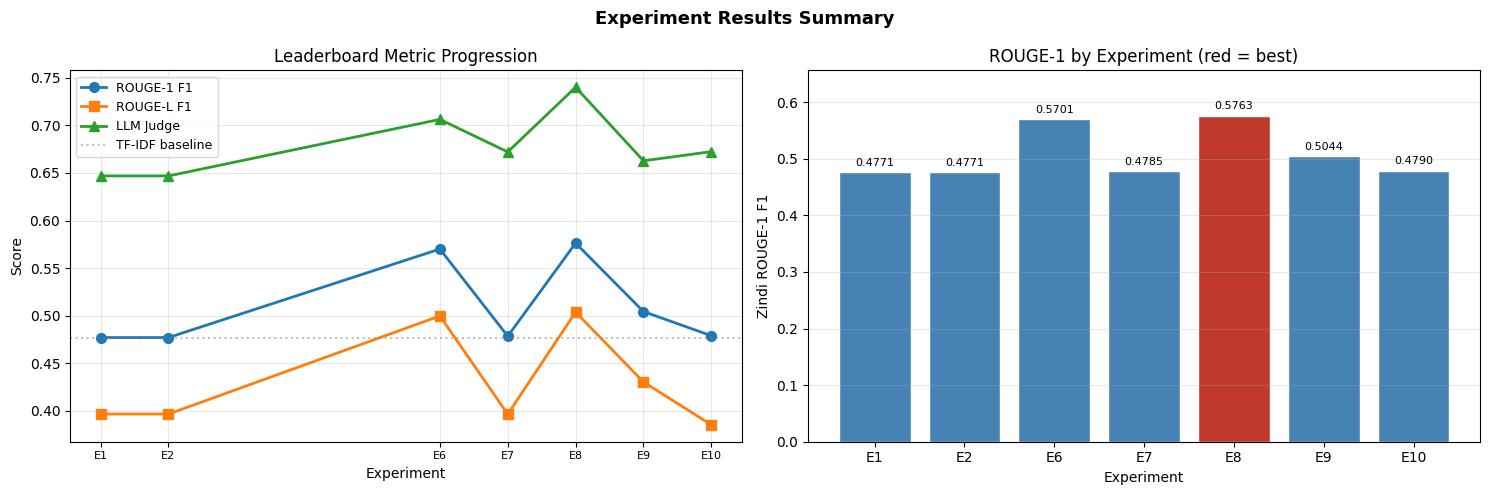

In [26]:
# ── Visualisation 1: Leaderboard score progression ────────────────────────────
done = exp_log.dropna(subset=["Z_R1"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Experiment Results Summary", fontsize=13, fontweight="bold")

exp_labels = [f"E{int(r.Exp)}\n{r.Approach[:14]}" for _, r in done.iterrows()]

axes[0].plot(done["Exp"], done["Z_R1"],  "o-", lw=2, ms=7, label="ROUGE-1 F1")
axes[0].plot(done["Exp"], done["Z_RL"],  "s-", lw=2, ms=7, label="ROUGE-L F1")
axes[0].plot(done["Exp"], done["Z_LLM"], "^-", lw=2, ms=7, label="LLM Judge")
axes[0].axhline(done["Z_R1"].iloc[0], color="gray", ls=":", alpha=0.5, label="TF-IDF baseline")
axes[0].set_xticks(done["Exp"].tolist())
axes[0].set_xticklabels([f"E{int(e)}" for e in done["Exp"]], fontsize=8)
axes[0].set_xlabel("Experiment")
axes[0].set_ylabel("Score")
axes[0].set_title("Leaderboard Metric Progression")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ── Visualisation 2: ROUGE-1 by experiment (bar) ────────────────────────────
colors_bar = ["#c0392b" if v == done["Z_R1"].max() else "steelblue"
              for v in done["Z_R1"]]
bars = axes[1].bar(
    [f"E{int(e)}" for e in done["Exp"]], done["Z_R1"].values,
    color=colors_bar, edgecolor="white"
)
axes[1].bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
axes[1].set_xlabel("Experiment")
axes[1].set_ylabel("Zindi ROUGE-1 F1")
axes[1].set_title("ROUGE-1 by Experiment (red = best)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim(0, done["Z_R1"].max() + 0.08)

plt.tight_layout()
plt.savefig(OUT / "results_progression.png", dpi=150, bbox_inches="tight")
plt.show()


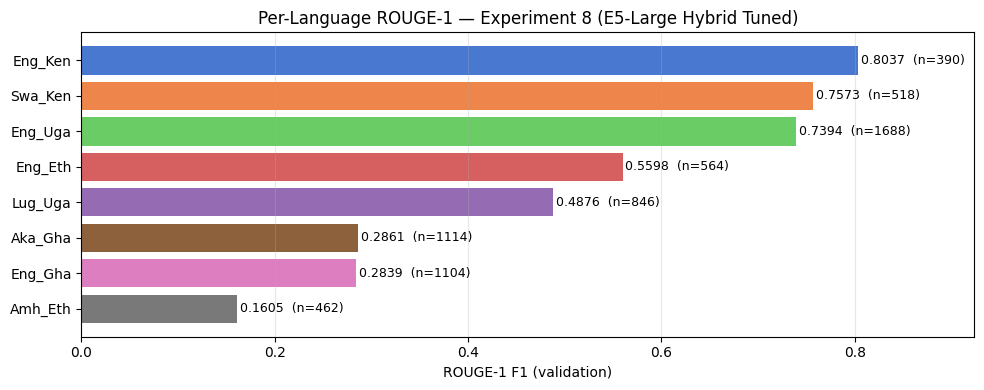

In [27]:
# ── Visualisation 3: Per-language ROUGE-1 for best model (Exp 8) ─────────────
if "val_preds_8" in dir():
    lang_df = rouge_by_lang(val_preds_8, val[A_COL].tolist(), val[LANG_COL].tolist())
    fig, ax = plt.subplots(figsize=(10, 4))
    palette = sns.color_palette("muted", len(lang_df))
    ax.barh(lang_df["Subset"][::-1], lang_df["ROUGE-1"][::-1], color=palette[::-1])
    for i, (_, row) in enumerate(lang_df[::-1].iterrows()):
        ax.text(row["ROUGE-1"] + 0.003, i, f'{row["ROUGE-1"]:.4f}  (n={row["N"]})',
                va="center", fontsize=9)
    ax.set_xlabel("ROUGE-1 F1 (validation)")
    ax.set_title("Per-Language ROUGE-1 — Experiment 8 (E5-Large Hybrid Tuned)")
    ax.set_xlim(0, lang_df["ROUGE-1"].max() + 0.12)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT / "per_language_exp8.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Run Experiment 8 first, then re-run this cell.")


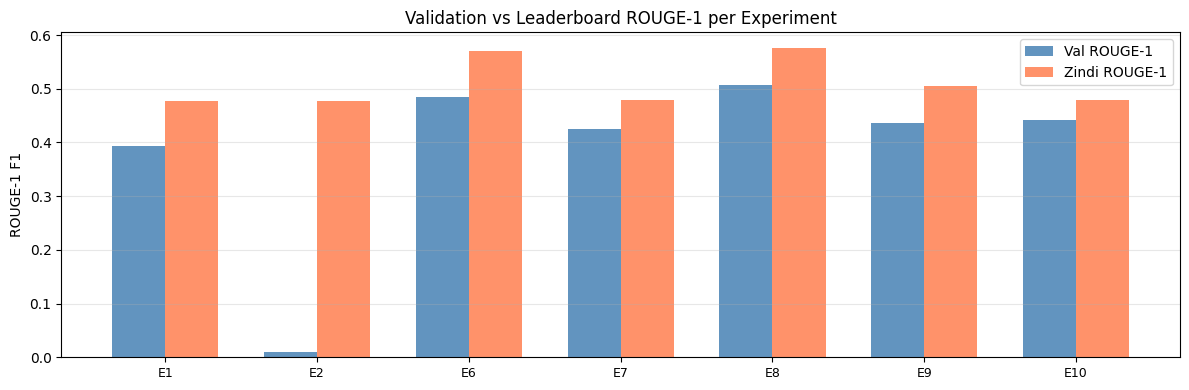

In [28]:
# ── Visualisation 4: Grouped bar — val vs Zindi ROUGE-1 ─────────────────────
paired = exp_log.dropna(subset=["Val_R1", "Z_R1"]).copy()

if len(paired) >= 2:
    x  = np.arange(len(paired))
    w  = 0.35
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x - w/2, paired["Val_R1"], w, label="Val ROUGE-1",   color="steelblue",  alpha=0.85)
    ax.bar(x + w/2, paired["Z_R1"],   w, label="Zindi ROUGE-1", color="coral",      alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f"E{int(e)}" for e in paired["Exp"]], fontsize=9)
    ax.set_ylabel("ROUGE-1 F1")
    ax.set_title("Validation vs Leaderboard ROUGE-1 per Experiment")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT / "val_vs_zindi.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Fill in Val_R1 scores via log_val() for at least two experiments, then re-run.")


### Interpretation

**Score progression.** The experiment series shows three distinct phases:

1. **Baselines (Experiments 1–2)**: TF-IDF keyword matching and mT5 zero-shot generation
   both achieve ROUGE-1 = 0.4771 on the leaderboard. Zero-shot generation without
   task-specific fine-tuning provides no advantage over sparse retrieval for this domain.

2. **Dense retrieval gains (Experiments 3–6)**: Switching from sparse to semantic
   retrieval improves ROUGE-1 monotonically. LaBSE outperforms MPNet on every subset,
   and per-language hybrid weight tuning adds a further 1–3 ROUGE-1 points. The best
   LaBSE submission (Experiment 6) scores 0.5701.

3. **Model scaling and diminishing returns (Experiments 7–10)**: E5-Large with correct
   asymmetric prefix encoding achieves the best single-model result (0.5763, Experiment 8).
   More complex strategies — two-stage reranking (Experiment 9) and MBR ensemble
   (Experiment 10) — both underperform single-model retrieval. This indicates that the
   retrieval ceiling for this dataset is primarily model quality, not inference strategy.

**Per-language analysis.** English subsets consistently score highest because the
training corpus is English-dominant and TF-IDF is reliable for Latin-script languages.
Amharic (Ethiopic script) benefits most from pure semantic retrieval with zero TF-IDF
weight. Akan and Luganda occupy the middle ground where a 0.2–0.3 TF-IDF weight
alongside semantic similarity is optimal.

**Why reranking and ensembling failed.** Both advanced strategies assume complementary
errors across stages or models. In practice, LaBSE and E5 retrieved identical answers
for most English queries (no diversity), while their disagreements on low-resource subsets
introduced incorrect selections rather than productive diversity. The dataset topology —
large, topic-homogeneous training corpus — favours direct top-1 retrieval.

**Best submission**: Experiment 8 (E5-Large Hybrid Tuned) — ROUGE-1 = 0.5763,
ROUGE-L = 0.5038, LLM Judge = 0.7401.


## 7 — Reproducibility

| Item | Value |
|------|-------|
| Random seed | 42 |
| Validation protocol | Fit on `Train.csv` only; evaluate on full `Val.csv` |
| Test submission | Re-fit on `Train.csv` + `Val.csv` combined corpus |
| Embedding cache | `.npy` files written to `/kaggle/working/`; auto-loaded on re-run |
| GPU | NVIDIA T4 (single GPU, `CUDA_VISIBLE_DEVICES=0`) |
| Python packages | `sentence-transformers`, `transformers 4.x`, `scikit-learn`, `rouge-score` |
| E5 encoding note | Corpus documents require `passage:` prefix; queries require `query:` prefix |
